In [23]:
# 加载数据和前期模型
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import time
import os 
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
import warnings
warnings.filterwarnings('ignore')

# 打印 XGBoost 版本
print(f"XGBoost 版本: {xgb.__version__}")

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n数据准备完成")
print(f"特征数: {X.shape[1]}")
print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 加载已训练的模型（用于对比）
try:
    best_dt = joblib.load('../models/day03_best_tree.pkl')
    best_rf = joblib.load('../models/day09_random_forest_tuned.pkl')
    print("\n✓ 已加载决策树和随机森林模型")
except:
    print("\n⚠️  未找到已保存的模型，将只训练 XGBoost")
    best_dt = None
    best_rf = None

XGBoost 版本: 3.3.0

数据准备完成
特征数: 135
训练集: 3811 样本
测试集: 953 样本

✓ 已加载决策树和随机森林模型


In [24]:
# 训练第一个模型
print("\n" + "="*70)
print("训练 XGBoost 模型（默认参数）")
print("="*70)

xgb_model = xgb.XGBRegressor(
    n_estimators=100,    # 100 棵树
    max_depth=6,         # 默认深度 6
    learning_rate=0.3,   # 默认学习率
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

print("\n开始训练...")
start_time = time.time()
xgb_model.fit(X_train, y_train, verbose=False)
train_time = time.time() - start_time

print(f"完成, 耗时 {train_time:.2f} 秒")

# 评估
train_r2 = xgb_model.score(X_train, y_train)
test_r2 = xgb_model.score(X_test, y_test)

print(f"\n训练集 R²: {train_r2:.4f}")
print(f"测试集 R²: {test_r2:.4f}")
print(f"差距:      {train_r2 - test_r2:.4f}")

# 和之前的模型对比
if best_dt is not None:
    print(f"\n决策树最佳:  {best_dt.score(X_test, y_test):.4f}")
if best_rf is not None:
    print(f"随机森林调优: {best_rf.score(X_test, y_test):.4f}")
print(f"XGBoost:      {test_r2:.4f}")


训练 XGBoost 模型（默认参数）

开始训练...
完成, 耗时 0.56 秒

训练集 R²: 0.9929
测试集 R²: 0.6178
差距:      0.3751

决策树最佳:  0.5781
随机森林调优: 0.6972
XGBoost:      0.6178


In [25]:
# 评估和对比
print("\n" + "="*70)
print("评估 XGBoost 性能")
print("="*70)

# 训练集评估
y_train_pred = xgb_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# 测试集评估
y_test_pred = xgb_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n训练集:")
print(f"  R²:   {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")

print(f"\n测试集:")
print(f"  R²:   {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")

# 过拟合检查
gap = train_r2 - test_r2
print(f"\n过拟合分析:")
print(f"  R² 差距: {gap:.4f}")
if gap < 0.05:
    print(f"  状态: ✓ 泛化能力良好")
elif gap < 0.10:
    print(f"  状态: ⚠ 轻微过拟合")
else:
    print(f"  状态: ✗ 过拟合")


评估 XGBoost 性能

训练集:
  R²:   0.9929
  RMSE: 0.0240
  MAE:  0.0132

测试集:
  R²:   0.6178
  RMSE: 0.1611
  MAE:  0.0657

过拟合分析:
  R² 差距: 0.3751
  状态: ✗ 过拟合


In [26]:
print("\n" + "="*70)
print("三模型性能对比")
print("="*70)

# 收集所有模型的结果
models_comparison = []

if best_dt is not None:
    dt_test_r2 = best_dt.score(X_test, y_test)
    dt_train_r2 = best_dt.score(X_train, y_train)
    models_comparison.append({
        'Model': 'Week 1: 决策树（最佳）',
        'Train_R2': dt_train_r2,
        'Test_R2': dt_test_r2,
        'Gap': dt_train_r2 - dt_test_r2,
        'Train_Time': 'N/A'
    })

if best_rf is not None:
    rf_test_r2 = best_rf.score(X_test, y_test)
    rf_train_r2 = best_rf.score(X_train, y_train)
    models_comparison.append({
        'Model': 'Week 2: 随机森林（调优）',
        'Train_R2': rf_train_r2,
        'Test_R2': rf_test_r2,
        'Gap': rf_train_r2 - rf_test_r2,
        'Train_Time': 'N/A'
    })

models_comparison.append({
    'Model': 'Week 3: XGBoost（默认）',
    'Train_R2': train_r2,
    'Test_R2': test_r2,
    'Gap': gap,
    'Train_Time': f'{train_time:.2f}s'
})

# 创建对比 DataFrame
comparison_df = pd.DataFrame(models_comparison)

print("\n性能对比表:\n")
print(comparison_df.to_string(index=False))

# 计算提升幅度
if best_rf is not None:
    improvement = test_r2 - rf_test_r2
    improvement_pct = (improvement / rf_test_r2) * 100
    print(f"\nXGBoost vs 随机森林:")
    print(f"  测试集 R² 提升: {improvement:+.4f} ({improvement_pct:+.2f}%)")


三模型性能对比

性能对比表:

              Model  Train_R2  Test_R2      Gap Train_Time
    Week 1: 决策树（最佳）  0.649914 0.578071 0.071844        N/A
   Week 2: 随机森林（调优）  0.825464 0.697165 0.128299        N/A
Week 3: XGBoost（默认）  0.992895 0.617751 0.375144      0.56s

XGBoost vs 随机森林:
  测试集 R² 提升: -0.0794 (-11.39%)


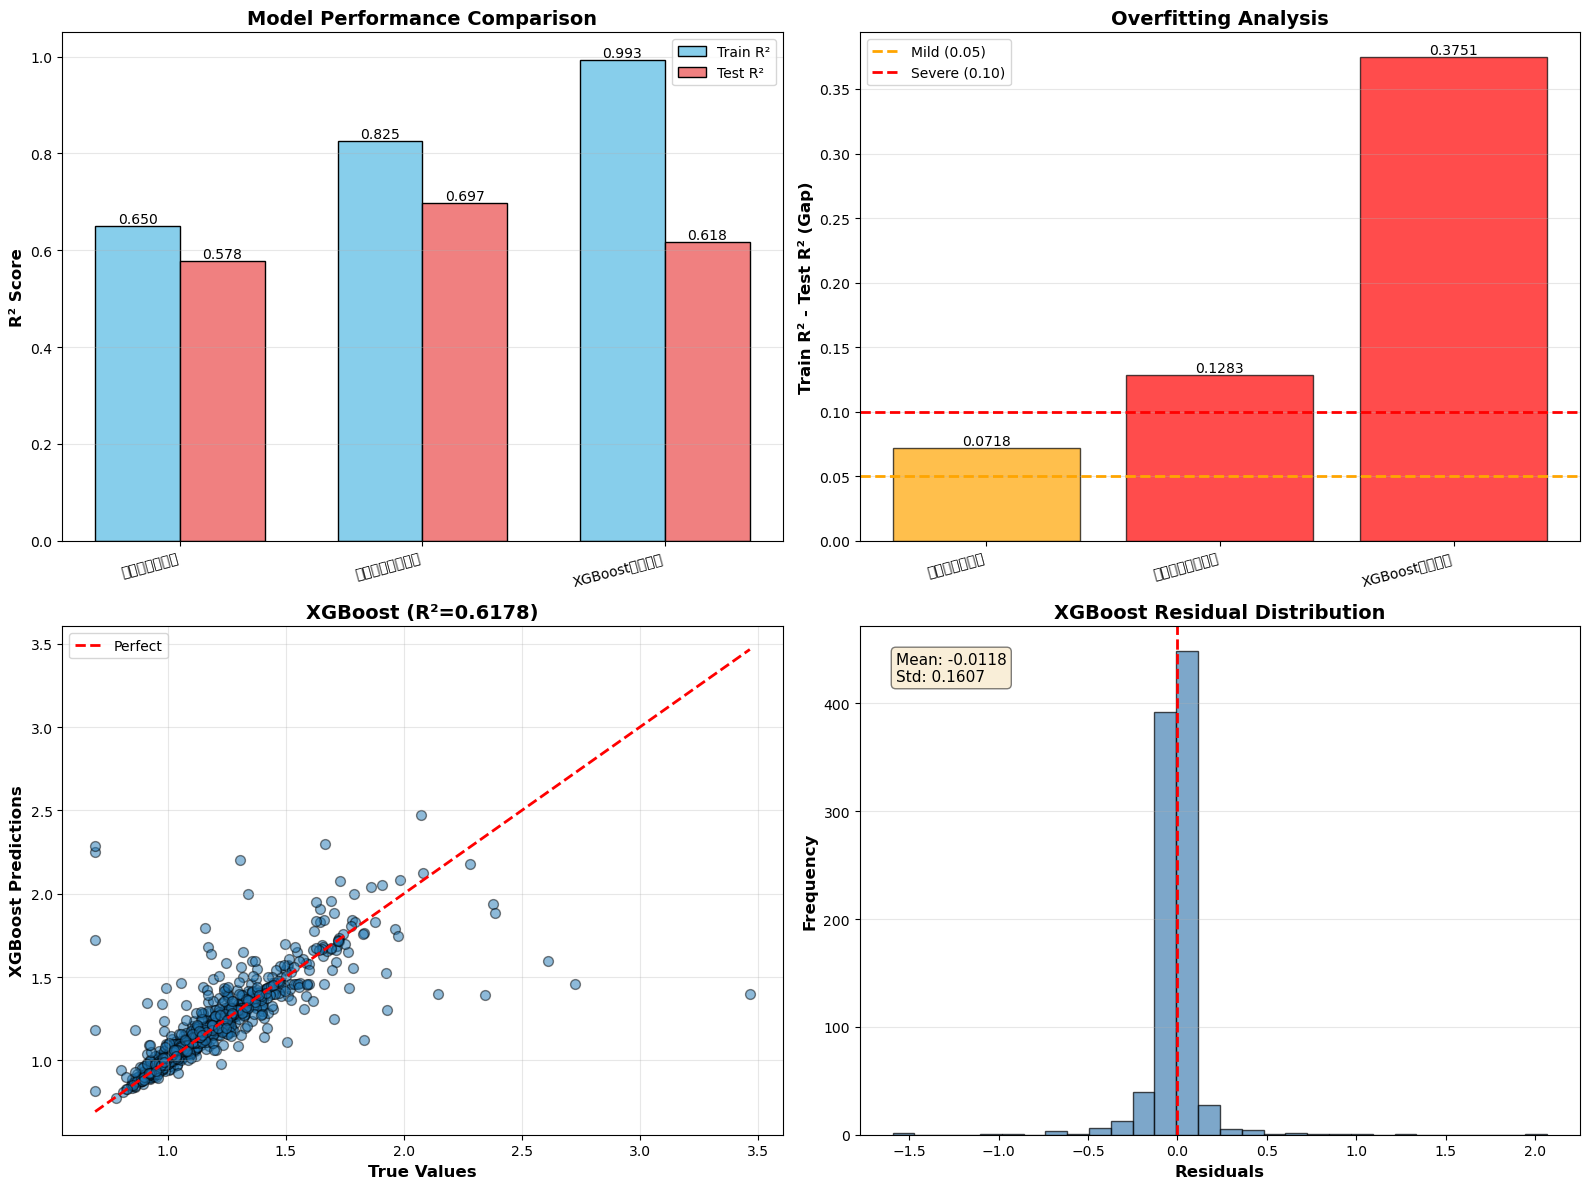


Image saved to ../figures/day15_xgb_comparison.png


In [27]:
# 可视化对比
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图 1：R² 对比
ax1 = axes[0, 0]
model_names = [m.split(':')[1].strip() for m in comparison_df['Model']]
x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_df['Train_R2'], width, 
                label='Train R²', color='skyblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, comparison_df['Test_R2'], width, 
                label='Test R²', color='lightcoral', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=15, ha='right')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1.05])

# 子图 2：过拟合程度对比
ax2 = axes[0, 1]
colors_gap = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' 
              for g in comparison_df['Gap']]

bars_gap = ax2.bar(x, comparison_df['Gap'], color=colors_gap, alpha=0.7, edgecolor='black')
ax2.axhline(0.05, color='orange', linestyle='--', linewidth=2, label='Mild (0.05)')
ax2.axhline(0.10, color='red', linestyle='--', linewidth=2, label='Severe (0.10)')

ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=15, ha='right')
ax2.set_ylabel('Train R² - Test R² (Gap)', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars_gap, comparison_df['Gap'])):
    ax2.text(bar.get_x() + bar.get_width()/2., val,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# 子图 3：XGBoost 预测 vs 真实值
ax3 = axes[1, 0]
ax3.scatter(y_test, y_test_pred, alpha=0.5, s=50, edgecolors='k')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect')
ax3.set_xlabel('True Values', fontsize=12, fontweight='bold')
ax3.set_ylabel('XGBoost Predictions', fontsize=12, fontweight='bold')
ax3.set_title(f'XGBoost (R²={test_r2:.4f})', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 子图 4：残差分析
ax4 = axes[1, 1]
residuals = y_test - y_test_pred
ax4.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax4.axvline(0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Residuals', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('XGBoost Residual Distribution', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

ax4.text(0.05, 0.95, f'Mean: {np.mean(residuals):.4f}\nStd: {np.std(residuals):.4f}', 
         transform=ax4.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../figures/day15_xgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImage saved to ../figures/day15_xgb_comparison.png")


特征重要性对比（XGBoost vs 随机森林）

Top 10 特征（XGBoost）:

                             feature  XGBoost_importance
MagpieData maximum Electronegativity            0.254271
          MagpieData mode NsUnfilled            0.109246
           MagpieData maximum Column            0.072705
         MagpieData minimum MeltingT            0.053265
           MagpieData mode NdValence            0.030951
      MagpieData minimum GSvolume_pa            0.026184
                             density            0.021218
        MagpieData avg_dev NpValence            0.020008
  MagpieData maximum MendeleevNumber            0.019071
           MagpieData mean NpValence            0.018413

Top 15 特征对比（XGBoost vs 随机森林）:

                             feature  XGBoost_importance  RF_importance  XGB_rank  RF_rank  Rank_diff
MagpieData maximum Electronegativity            0.254271       0.150941         1        1          0
          MagpieData mode NsUnfilled            0.109246       0.000953         2       9

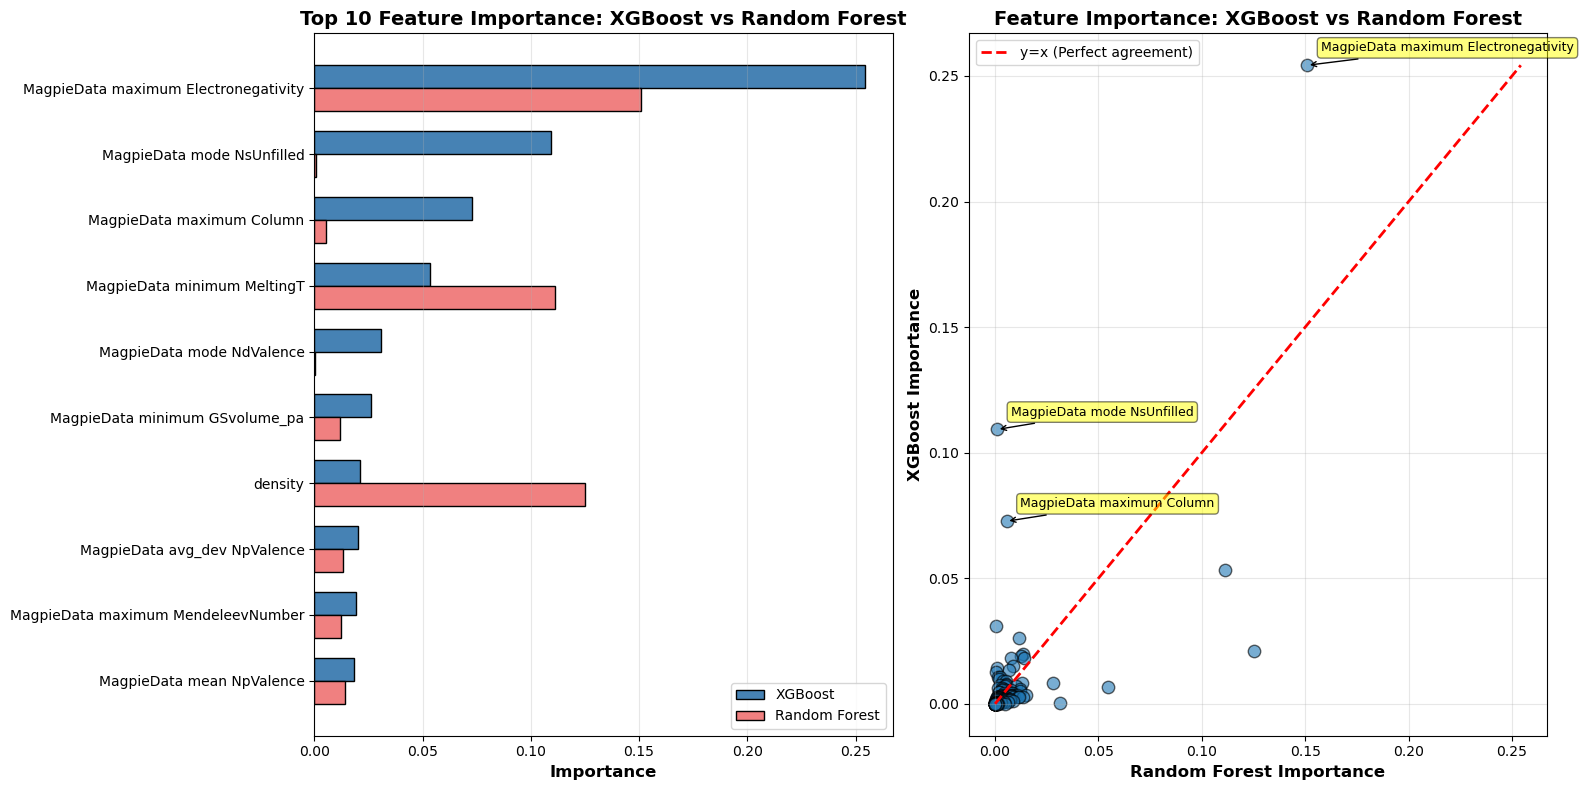


✓ 特征重要性对比图已保存

排名变化 > 5 的特征（共 113 个）:

                          feature  XGB_rank  RF_rank  Rank_diff
        MagpieData mode NdValence         5      110        105
       MagpieData mode NsUnfilled         2       97         95
MagpieData minimum CovalentRadius       100        5        -95
     MagpieData minimum NdValence        15      108         93
       MagpieData mode NdUnfilled        13      102         89
     MagpieData maximum NpValence       123       49        -74
        MagpieData mode GSbandgap        16       89         73
   MagpieData mode CovalentRadius        88       23        -65
    MagpieData avg_dev NsUnfilled        18       81         63
           MagpieData mode Column        29       88         59


In [28]:
print("\n" + "="*70)
print("特征重要性对比（XGBoost vs 随机森林）")
print("="*70)

# 获取 XGBoost 特征重要性
xgb_importances = xgb_model.feature_importances_

xgb_imp_df = pd.DataFrame({
    'feature': X.columns,
    'XGBoost_importance': xgb_importances
}).sort_values('XGBoost_importance', ascending=False).reset_index(drop=True)

print("\nTop 10 特征（XGBoost）:\n")
print(xgb_imp_df.head(10).to_string(index=False))

# 如果有随机森林，进行对比
if best_rf is not None:
    rf_importances = best_rf.feature_importances_
    
    # 合并对比
    importance_comparison = xgb_imp_df.merge(
        pd.DataFrame({'feature': X.columns, 'RF_importance': rf_importances}),
        on='feature'
    ).sort_values('XGBoost_importance', ascending=False)
    
    # 添加排名
    importance_comparison['XGB_rank'] = importance_comparison['XGBoost_importance'].rank(ascending=False).astype(int)
    importance_comparison['RF_rank'] = importance_comparison['RF_importance'].rank(ascending=False).astype(int)
    importance_comparison['Rank_diff'] = importance_comparison['RF_rank'] - importance_comparison['XGB_rank']
    
    print("\nTop 15 特征对比（XGBoost vs 随机森林）:\n")
    print(importance_comparison.head(15)[
        ['feature', 'XGBoost_importance', 'RF_importance', 'XGB_rank', 'RF_rank', 'Rank_diff']
    ].to_string(index=False))
    
    # 可视化对比
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 左图：Top 10 对比
    ax1 = axes[0]
    top10_comp = importance_comparison.head(10)
    x_pos = np.arange(len(top10_comp))
    width = 0.35
    
    bars1 = ax1.barh(x_pos - width/2, top10_comp['XGBoost_importance'], width,
                     label='XGBoost', color='steelblue', edgecolor='black')
    bars2 = ax1.barh(x_pos + width/2, top10_comp['RF_importance'], width,
                     label='Random Forest', color='lightcoral', edgecolor='black')
    
    ax1.set_yticks(x_pos)
    ax1.set_yticklabels(top10_comp['feature'])
    ax1.invert_yaxis()
    ax1.set_xlabel('Importance', fontsize=12, fontweight='bold')
    ax1.set_title('Top 10 Feature Importance: XGBoost vs Random Forest', 
                  fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='x')
    
    # 右图：散点图（所有特征）
    ax2 = axes[1]
    ax2.scatter(importance_comparison['RF_importance'], 
                importance_comparison['XGBoost_importance'],
                alpha=0.6, s=80, edgecolors='k')
    
    # 添加 y=x 参考线
    max_imp = max(importance_comparison['RF_importance'].max(), 
                  importance_comparison['XGBoost_importance'].max())
    ax2.plot([0, max_imp], [0, max_imp], 'r--', lw=2, label='y=x (Perfect agreement)')
    
    # 标注 Top 3 特征
    for i, row in importance_comparison.head(3).iterrows():
        ax2.annotate(row['feature'], 
                     xy=(row['RF_importance'], row['XGBoost_importance']),
                     xytext=(10, 10), textcoords='offset points',
                     fontsize=9, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
                     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    ax2.set_xlabel('Random Forest Importance', fontsize=12, fontweight='bold')
    ax2.set_ylabel('XGBoost Importance', fontsize=12, fontweight='bold')
    ax2.set_title('Feature Importance: XGBoost vs Random Forest', 
                  fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/day15_importance_xgb_vs_rf.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ 特征重要性对比图已保存")
    
    # 分析排名变化大的特征
    rank_change_large = importance_comparison[abs(importance_comparison['Rank_diff']) > 5].sort_values(
        'Rank_diff', key=abs, ascending=False
    )
    
    if len(rank_change_large) > 0:
        print(f"\n排名变化 > 5 的特征（共 {len(rank_change_large)} 个）:\n")
        print(rank_change_large.head(10)[
            ['feature', 'XGB_rank', 'RF_rank', 'Rank_diff']
        ].to_string(index=False))


XGBoost 训练过程分析

训练并记录每轮性能...


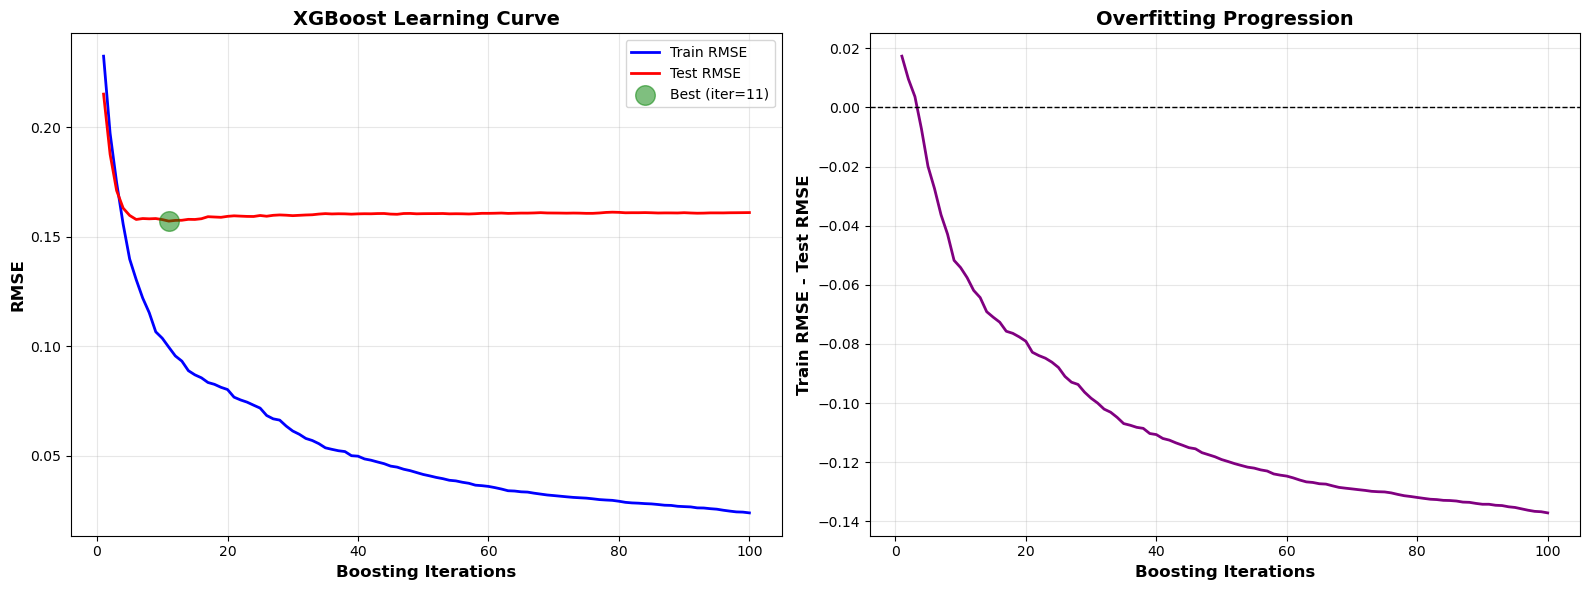


Learning curve saved

Key observations:
  Best iteration: 11
  Best test RMSE: 0.1572
  Final train RMSE: 0.0240
  Final test RMSE: 0.1611


In [32]:
# 可视化训练过程
print("\n" + "="*70)
print("XGBoost 训练过程分析")
print("="*70)

eval_set = [(X_train, y_train), (X_test, y_test)]

xgb_trace = xgb.XGBRegressor(
    n_estimators=100, max_depth=6, learning_rate=0.3,
    random_state=42, n_jobs=-1
)

print("\n训练并记录每轮性能...")
xgb_trace.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 获取训练历史（注意：这些是列表，别和 cell 2 的标量混淆）
results = xgb_trace.evals_result()
trace_train = results['validation_0']['rmse']   # 列表：100 轮的训练误差
trace_test = results['validation_1']['rmse']     # 列表：100 轮的测试误差

# 可视化学习曲线
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
epochs = range(1, len(trace_train) + 1)
ax1.plot(epochs, trace_train, label='Train RMSE', linewidth=2, color='blue')
ax1.plot(epochs, trace_test, label='Test RMSE', linewidth=2, color='red')
ax1.set_xlabel('Boosting Iterations', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('XGBoost Learning Curve', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

best_iter = np.argmin(trace_test) + 1
best_test_rmse_val = min(trace_test)
ax1.scatter(best_iter, best_test_rmse_val, s=200, color='green',
            zorder=5, alpha=0.5, label=f'Best (iter={best_iter})')
ax1.legend()

ax2 = axes[1]
gap_rmse = np.array(trace_train) - np.array(trace_test)
ax2.plot(epochs, gap_rmse, linewidth=2, color='purple')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('Boosting Iterations', fontsize=12, fontweight='bold')
ax2.set_ylabel('Train RMSE - Test RMSE', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting Progression', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day15_xgb_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLearning curve saved")
print(f"\nKey observations:")
print(f"  Best iteration: {best_iter}")
print(f"  Best test RMSE: {best_test_rmse_val:.4f}")
print(f"  Final train RMSE: {trace_train[-1]:.4f}")
print(f"  Final test RMSE: {trace_test[-1]:.4f}")

In [33]:
# 保存 XGBoost 模型
joblib.dump(xgb_model, '../models/day15_xgboost_default.pkl')
print("\nXGBoost saved to ../models/day15_xgboost_default.pkl")

# 保存对比结果
import json

def to_py(val):
    if isinstance(val, (int, np.integer)): return int(val)
    if isinstance(val, (float, np.floating)): return float(val)
    if isinstance(val, dict): return {k: to_py(v) for k, v in val.items()}
    if isinstance(val, list): return [to_py(v) for v in val]
    return str(val)

# 从 get_params() 取参数（XGBoost 3.x 属性访问返回 None）
params = xgb_model.get_params()

comparison_summary = {
    'models': to_py(comparison_df.to_dict('records')),
    'xgboost_params': {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': float(params['learning_rate'])
    },
    'performance': {
        'train_r2': float(train_r2),
        'test_r2': float(test_r2),
        'train_rmse': float(train_rmse),
        'test_rmse': float(test_rmse),
        'overfitting_gap': float(gap)
    }
}

with open('../models/day15_xgb_comparison.json', 'w') as f:
    json.dump(comparison_summary, f, indent=2)

print("Comparison saved")

# 打印最终总结
print("\n" + "="*70)
print("Day 15 Summary")
print("="*70)

print(f"\nPerformance comparison:")
for i, row in comparison_df.iterrows():
    print(f"  {row['Model']:30s} Test R²={row['Test_R2']:.4f}, Gap={row['Gap']:.4f}")

if best_rf is not None:
    print(f"\nXGBoost vs RF:")
    print(f"  Test R² change: {test_r2 - rf_test_r2:+.4f}")
    if test_r2 > rf_test_r2:
        print(f"  XGBoost better (+{(test_r2 - rf_test_r2)/rf_test_r2*100:.2f}%)")
    elif abs(test_r2 - rf_test_r2) < 0.01:
        print(f"  Equal (within 0.01)")
    else:
        print(f"  RF better, XGBoost needs tuning")

print(f"\nKey findings:")
print(f"  1. XGBoost with boosting + shallow trees (depth={int(params['max_depth'])})")
print(f"  2. Feature importance Top 3:")
for i, row in xgb_imp_df.head(3).iterrows():
    print(f"     {i+1}. {row['feature']}")
print("="*70)


XGBoost saved to ../models/day15_xgboost_default.pkl


TypeError: float() argument must be a string or a real number, not 'list'